# BCI Competition IV Dataset 2a — Dual Pipeline
## Pipeline A: Filter Bank CSP + LDA  (classical, competition-winning approach)
## Pipeline B: EEGNet with strong augmentation + subject-adaptive tuning

### Why two pipelines?
- Bad performers (A04, A05, A06, A09) have weak/inconsistent motor imagery signals
- Deep learning needs large data; CSP works well even with 72 trials per class
- Competition winner (kappa=0.57) used Filter Bank CSP
- Final result = best of both per subject

### True labels download:
https://www.bbci.de/competition/iv/results/ds2a/true_labels.zip
Place .mat files in: `/content/drive/MyDrive/BCI_IV_2a/true_labels/`

## Step 1: Mount Drive & Verify Files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATA_PATH        = "/content/drive/MyDrive/BCI_IV_2a"
TRUE_LABELS_PATH = "/content/drive/MyDrive/BCI_IV_2a/true_labels"

print("=== GDF files ===")
for f in sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.gdf')]):
    print(f)

print("\n=== True label files ===")
if os.path.exists(TRUE_LABELS_PATH):
    for f in sorted(os.listdir(TRUE_LABELS_PATH)):
        print(f)
else:
    print("ERROR: Download true labels from:")
    print("https://www.bbci.de/competition/iv/results/ds2a/true_labels.zip")

=== GDF files ===
A01E.gdf
A01T.gdf
A02E.gdf
A02T.gdf
A03E.gdf
A03T.gdf
A04E.gdf
A04T.gdf
A05E.gdf
A05T.gdf
A06E.gdf
A06T.gdf
A07E.gdf
A07T.gdf
A08E.gdf
A08T.gdf
A09E.gdf
A09T.gdf

=== True label files ===
A01E.mat
A01T.mat
A02E.mat
A02T.mat
A03E.mat
A03T.mat
A04E.mat
A04T.mat
A05E.mat
A05T.mat
A06E.mat
A06T.mat
A07E.mat
A07T.mat
A08E.mat
A08T.mat
A09E.mat
A09T.mat


## Step 2: Install & Import

In [3]:
!pip install mne scipy torch torchvision scikit-learn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 104.1 MB/s eta 0:00:00


In [4]:
import os
import copy
import warnings
import numpy as np
import mne
from scipy.io import loadmat
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, cohen_kappa_score, \
                            confusion_matrix, classification_report

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print("All libraries loaded.")

Device : cuda
All libraries loaded.


## Step 3: Data Loading Functions (unchanged from v2)

In [5]:
def load_train_data(file_path, tmin=3.0, tmax=6.0):
    """
    Load A0xT.gdf. Labels from embedded events 769-772.
    Returns raw numpy array (no filtering applied here —
    FBCSP applies its own per-band filtering).
    """
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=False)
    eog = [ch for ch in ['EOG-left','EOG-central','EOG-right'] if ch in raw.ch_names]
    raw.drop_channels(eog)

    # Broad bandpass — FBCSP will re-filter per band
    raw.filter(4., 40., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    mi_map      = {'769':0, '770':1, '771':2, '772':3}
    code_to_name = {v: k for k, v in event_dict.items()}

    sel_events, labels = [], []
    for ev in events:
        name = code_to_name.get(ev[2], None)
        if name in mi_map:
            sel_events.append(ev)
            labels.append(mi_map[name])

    sel_events = np.array(sel_events, dtype=int)
    labels     = np.array(labels, dtype=int)

    epochs = mne.Epochs(raw, sel_events, tmin=tmin, tmax=tmax,
                        baseline=None, preload=True, verbose=False)
    data   = epochs.get_data()
    labels = labels[:data.shape[0]]

    sfreq = raw.info['sfreq']
    print(f"  Train: {data.shape}  sfreq={sfreq}Hz  classes={dict(zip(*np.unique(labels, return_counts=True)))}")
    return data, labels, sfreq


def load_eval_data(gdf_path, mat_path, tmin=3.0, tmax=6.0):
    """
    Load A0xE.gdf + true labels from .mat.
    Cue event in eval files = 783.
    """
    mat         = loadmat(mat_path)
    true_labels = mat['classlabel'].flatten().astype(int) - 1

    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)
    eog = [ch for ch in ['EOG-left','EOG-central','EOG-right'] if ch in raw.ch_names]
    raw.drop_channels(eog)
    raw.filter(4., 40., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    cue_code   = event_dict.get('783', None)
    if cue_code is None:
        raise ValueError(f"Event 783 not found. Available: {list(event_dict.keys())}")

    cue_events = events[events[:, 2] == cue_code]
    n = min(len(cue_events), len(true_labels))
    cue_events, true_labels = cue_events[:n], true_labels[:n]

    epochs = mne.Epochs(raw, cue_events, tmin=tmin, tmax=tmax,
                        baseline=None, preload=True, verbose=False)
    data        = epochs.get_data()
    true_labels = true_labels[:data.shape[0]]

    sfreq = raw.info['sfreq']
    print(f"  Eval:  {data.shape}  sfreq={sfreq}Hz  classes={dict(zip(*np.unique(true_labels, return_counts=True)))}")
    return data, true_labels, sfreq

## Step 4: Pipeline A — Filter Bank CSP + LDA

### How FBCSP works:
```
Raw EEG (22ch × T)
    │
    ├─► Band 1 (4-8 Hz)   → CSP → log-variance features
    ├─► Band 2 (8-12 Hz)  → CSP → log-variance features   ← mu rhythm
    ├─► Band 3 (12-16 Hz) → CSP → log-variance features
    ├─► Band 4 (16-20 Hz) → CSP → log-variance features   ← beta rhythm
    ├─► Band 5 (20-24 Hz) → CSP → log-variance features
    └─► Band 6 (24-40 Hz) → CSP → log-variance features
         │
    Concatenate all features
         │
    LDA Classifier → predicted class
```
CSP finds spatial filters that maximize variance for one class
while minimizing it for another — directly suited for motor imagery.

In [6]:
# ─────────────────────────────────────────────────────────────
# FILTER BANK DEFINITION
# Covers mu (8-12) and beta (13-30) bands plus surrounding context
# ─────────────────────────────────────────────────────────────
FILTER_BANKS = [
    (4,  8),    # below mu
    (8,  12),   # mu band
    (12, 16),   # low beta
    (16, 20),   # mid beta
    (20, 24),   # high beta
    (24, 32),   # gamma
]


def bandpass_filter(data, low, high, sfreq, order=4):
    """
    Apply zero-phase Butterworth bandpass filter.

    Args:
        data  : (n_trials, n_channels, n_samples)
        low   : lower cutoff Hz
        high  : upper cutoff Hz
        sfreq : sampling frequency
        order : filter order
    Returns:
        filtered data of same shape
    """
    nyq  = sfreq / 2.0
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)


def compute_csp(X_class1, X_class2, n_components=4):
    """
    Compute Common Spatial Pattern filters.

    CSP finds spatial filters W such that:
    - Variance of W^T * X_class1 is maximized
    - Variance of W^T * X_class2 is minimized
    (and vice versa for the last components)

    Args:
        X_class1    : (n1, channels, samples) for class 1
        X_class2    : (n2, channels, samples) for class 2
        n_components: number of CSP filters to return (take first+last)
    Returns:
        W : (channels, n_components) spatial filter matrix
    """
    # Covariance matrices averaged across trials
    def cov(X):
        # X: (trials, channels, samples)
        covs = [np.cov(X[i]) for i in range(X.shape[0])]
        return np.mean(covs, axis=0)

    C1 = cov(X_class1)
    C2 = cov(X_class2)
    Cc = C1 + C2   # composite covariance

    # Solve generalized eigenvalue problem: C1 * W = lambda * Cc * W
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(Cc) @ C1)

    # Sort by eigenvalue descending
    order   = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    # Take first and last n_components//2 filters
    half = n_components // 2
    W    = np.concatenate([eigvecs[:, :half],
                            eigvecs[:, -half:]], axis=1)
    return W.real


def extract_csp_features(X, W):
    """
    Apply CSP filter W to data X and extract log-variance features.

    Args:
        X : (n_trials, channels, samples)
        W : (channels, n_components) CSP filters
    Returns:
        features : (n_trials, n_components) log-variance features
    """
    # Apply spatial filter: W=(channels, n_comp), X=(trials, channels, samples)
    # W.T @ X[i] = (n_comp, channels) @ (channels, samples) = (n_comp, samples)
    # np.einsum: 'ck,nks->ncs' where c=n_comp, k=channels, s=samples
    Z = np.einsum('ck,nks->ncs', W.T, X)  # (trials, n_comp, samples)

    # Log-variance of each component across time
    var      = np.var(Z, axis=-1)          # (trials, n_comp)
    log_var  = np.log(var + 1e-10)         # log stabilizes scale
    return log_var


class FilterBankCSP:
    """
    One-vs-Rest Filter Bank CSP classifier.

    For a 4-class problem, trains 4 binary CSP+LDA classifiers
    (one per class vs. all others), then combines their confidence
    scores to make the final prediction.

    This is the standard approach used in BCI competition winners.
    """

    def __init__(self, filter_banks=None, n_csp=4, classifier='lda'):
        """
        Args:
            filter_banks : list of (low, high) Hz tuples
            n_csp        : number of CSP components per band
            classifier   : 'lda' or 'svm'
        """
        self.filter_banks = filter_banks or FILTER_BANKS
        self.n_csp        = n_csp
        self.classifier   = classifier
        self.csp_filters  = {}   # {class_idx: {band_idx: W}}
        self.classifiers  = {}   # {class_idx: sklearn classifier}

    def _get_features(self, X, sfreq, class_idx):
        """
        Extract FBCSP features for a given class's CSP filters.
        """
        all_feats = []
        for b_idx, (low, high) in enumerate(self.filter_banks):
            X_filt = bandpass_filter(X, low, high, sfreq)
            W      = self.csp_filters[class_idx][b_idx]
            feats  = extract_csp_features(X_filt, W)
            all_feats.append(feats)
        return np.concatenate(all_feats, axis=1)

    def fit(self, X, y, sfreq):
        """
        Train one CSP+classifier per class (one-vs-rest).

        Args:
            X     : (n_trials, n_channels, n_samples)
            y     : (n_trials,) integer class labels 0-3
            sfreq : sampling frequency in Hz
        """
        self.sfreq   = sfreq
        self.classes = np.unique(y)

        for cls in self.classes:
            # One-vs-rest split
            X_cls   = X[y == cls]
            X_rest  = X[y != cls]

            # Learn CSP filter for each frequency band
            self.csp_filters[cls] = {}
            for b_idx, (low, high) in enumerate(self.filter_banks):
                X_cls_filt  = bandpass_filter(X_cls,  low, high, sfreq)
                X_rest_filt = bandpass_filter(X_rest, low, high, sfreq)
                W = compute_csp(X_cls_filt, X_rest_filt, n_components=self.n_csp)
                self.csp_filters[cls][b_idx] = W

            # Extract features for all training trials using this class's filters
            X_feats = self._get_features(X, sfreq, cls)
            y_bin   = (y == cls).astype(int)   # binary labels: this class vs rest

            # Train binary classifier
            if self.classifier == 'lda':
                clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
            else:
                clf = Pipeline([
                    ('scaler', StandardScaler()),
                    ('svm',   SVC(kernel='rbf', probability=True, C=10.0))
                ])
            clf.fit(X_feats, y_bin)
            self.classifiers[cls] = clf

        return self

    def predict_proba(self, X):
        """
        Get confidence scores for each class.
        Returns (n_trials, n_classes) array.
        """
        scores = np.zeros((X.shape[0], len(self.classes)))
        for cls in self.classes:
            X_feats          = self._get_features(X, self.sfreq, cls)
            proba            = self.classifiers[cls].predict_proba(X_feats)
            scores[:, cls]   = proba[:, 1]   # probability of being this class
        return scores

    def predict(self, X):
        """
        Predict class labels by taking argmax of confidence scores.
        """
        return np.argmax(self.predict_proba(X), axis=1)

## Step 5: Pipeline B — EEGNet (same as v2 with improvements)
Dynamic FC size, dropout=0.5, used alongside FBCSP.

In [7]:
class EEGDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class EEGNet(nn.Module):
    def __init__(self, num_classes=4, n_channels=22, n_samples=751,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1*D, (n_channels,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1,4)),
            nn.Dropout(dropout)
        )
        self.separable = nn.Sequential(
            nn.Conv2d(F1*D, F2, (1,16), padding=(0,8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1,8)),
            nn.Dropout(dropout)
        )
        self._fc_size = self._get_fc_size(n_channels, n_samples)
        self.fc = nn.Linear(self._fc_size, num_classes)

    def _get_fc_size(self, n_channels, n_samples):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.depthwise(x)
            x = self.separable(x)
        return int(np.prod(x.shape[1:]))

    def forward(self, x):
        x = self.firstconv(x)
        x = self.depthwise(x)
        x = self.separable(x)
        return self.fc(torch.flatten(x, 1))


def augment_eeg(X, y, noise_std=0.05, n_augment=2, seed=42):
    rng    = np.random.default_rng(seed)
    sig_std = np.std(X)
    Xl, yl = [X], [y]
    for _ in range(n_augment):
        Xl.append(X + rng.standard_normal(X.shape) * noise_std * sig_std)
        yl.append(y)
    Xa, ya = np.concatenate(Xl), np.concatenate(yl)
    idx = rng.permutation(len(ya))
    return Xa[idx], ya[idx]


def train_eegnet(X_train, y_train, X_eval, y_eval,
                 n_channels, n_samples,
                 epochs=500, batch_size=16, patience=50):
    """
    Train EEGNet with early stopping.
    Returns predictions on X_eval.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2,
        random_state=42, stratify=y_train
    )

    tr_dl  = DataLoader(EEGDataset(X_tr,   y_tr),   batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(EEGDataset(X_val,  y_val),  batch_size=batch_size, shuffle=False)
    ev_dl  = DataLoader(EEGDataset(X_eval, y_eval), batch_size=batch_size, shuffle=False)

    model     = EEGNet(num_classes=4, n_channels=n_channels, n_samples=n_samples).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val   = float('inf')
    best_wts   = copy.deepcopy(model.state_dict())
    pat_ctr    = 0
    best_epoch = 0

    for epoch in range(epochs):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            nn.CrossEntropyLoss(label_smoothing=0.1)(model(Xb), yb).backward()
            optimizer.step()

        model.eval()
        vl = sum(criterion(model(Xb.to(device)), yb.to(device)).item()
                 for Xb, yb in val_dl)
        scheduler.step()

        if vl < best_val:
            best_val   = vl
            best_wts   = copy.deepcopy(model.state_dict())
            pat_ctr    = 0
            best_epoch = epoch + 1
        else:
            pat_ctr += 1
        if pat_ctr >= patience:
            break

    model.load_state_dict(best_wts)
    print(f"  EEGNet best epoch: {best_epoch}")

    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in ev_dl:
            preds.extend(torch.argmax(model(Xb.to(device)), dim=1).cpu().numpy())
    return np.array(preds)

## Step 6: Full Subject Pipeline

For each subject:
1. Run **FBCSP+LDA** on full training set → eval probabilities
2. Train **EEGNet** (single training, returns both hard preds + probabilities)
3. **Adaptive ensemble**: weight = cross-validated accuracy on training data
   - Subject where FBCSP CV-acc >> EEGNet CV-acc → weight FBCSP heavily
   - Subject where EEGNet wins on CV → weight EEGNet heavily
   - No more fixed 60/40 — weights are learned per subject from training data only

In [8]:
from sklearn.model_selection import StratifiedKFold


def cv_accuracy_fbcsp(X_raw, y, sfreq, n_splits=4):
    """
    Estimate FBCSP generalisation accuracy via stratified k-fold CV
    on the training data. Used only to set ensemble weights.
    Returns mean CV accuracy (float).
    """
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs = []
    for tr_idx, va_idx in skf.split(X_raw, y):
        clf = FilterBankCSP(filter_banks=FILTER_BANKS, n_csp=4, classifier='lda')
        clf.fit(X_raw[tr_idx], y[tr_idx], sfreq)
        preds = clf.predict(X_raw[va_idx])
        accs.append(accuracy_score(y[va_idx], preds))
    return float(np.mean(accs))


def train_eegnet_full(X_4d, y, n_channels, n_samples,
                      epochs=500, batch_size=16, patience=50):
    """
    Train EEGNet with early stopping. Returns (model, cv_accuracy).
    cv_accuracy is measured on the internal 20% validation split —
    used for adaptive ensemble weighting.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_4d, y, test_size=0.2, random_state=42, stratify=y
    )
    tr_dl  = DataLoader(EEGDataset(X_tr,  y_tr),  batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(EEGDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model     = EEGNet(num_classes=4, n_channels=n_channels, n_samples=n_samples).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val, best_wts, pat_ctr, best_epoch = float('inf'), copy.deepcopy(model.state_dict()), 0, 0

    for epoch in range(epochs):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(Xb), yb).backward()
            optimizer.step()
        model.eval()
        vl = sum(criterion(model(Xb.to(device)), yb.to(device)).item() for Xb, yb in val_dl)
        scheduler.step()
        if vl < best_val:
            best_val, best_wts, pat_ctr, best_epoch = vl, copy.deepcopy(model.state_dict()), 0, epoch+1
        else:
            pat_ctr += 1
        if pat_ctr >= patience:
            break

    model.load_state_dict(best_wts)
    print(f"  EEGNet best epoch: {best_epoch}")

    # Measure val accuracy at best checkpoint — used for ensemble weight
    model.eval()
    val_preds = []
    with torch.no_grad():
        for Xb, _ in val_dl:
            val_preds.extend(torch.argmax(model(Xb.to(device)), dim=1).cpu().numpy())
    val_acc = accuracy_score(y_val, val_preds)

    return model, float(val_acc)


def get_eegnet_probas(model, X_4d):
    """Get softmax probabilities from a trained EEGNet model."""
    dl    = DataLoader(EEGDataset(X_4d, np.zeros(len(X_4d), dtype=int)),
                       batch_size=32, shuffle=False)
    proba = []
    model.eval()
    with torch.no_grad():
        for Xb, _ in dl:
            proba.extend(torch.softmax(model(Xb.to(device)), dim=1).cpu().numpy())
    return np.array(proba)


def run_subject_full(subject_id, data_path, labels_path):
    """
    Run FBCSP+LDA and EEGNet for one subject with adaptive ensemble weighting.

    Ensemble weight is determined by cross-validated accuracy on training data:
        w_csp  = cv_acc_csp  / (cv_acc_csp + cv_acc_eeg)
        w_eeg  = cv_acc_eeg  / (cv_acc_csp + cv_acc_eeg)

    This means subjects where FBCSP dominates get FBCSP-heavy weighting,
    and subjects where EEGNet dominates (e.g. A03, A08, A09) get EEGNet-heavy
    weighting — automatically, without any manual tuning.
    """
    print(f"\n{'='*60}")
    print(f" Subject A0{subject_id}")
    print(f"{'='*60}")

    train_gdf = os.path.join(data_path,   f"A0{subject_id}T.gdf")
    eval_gdf  = os.path.join(data_path,   f"A0{subject_id}E.gdf")
    eval_mat  = os.path.join(labels_path, f"A0{subject_id}E.mat")

    # ── Load ──────────────────────────────────────────────────
    print("Loading...")
    Xt_raw, yt, sfreq = load_train_data(train_gdf)
    Xe_raw, ye, _     = load_eval_data(eval_gdf, eval_mat)

    # ── Normalize (train stats only) ──────────────────────────
    mean    = np.mean(Xt_raw, axis=(0,2), keepdims=True)
    std     = np.std(Xt_raw,  axis=(0,2), keepdims=True)
    std     = np.where(std < 1e-8, 1e-8, std)
    Xt_norm = (Xt_raw - mean) / std
    Xe_norm = (Xe_raw - mean) / std

    # ══════════════════════════════════════════════════════════
    # PIPELINE A: FBCSP + LDA
    # Step 1: CV accuracy on train (for ensemble weighting)
    # Step 2: Full fit on all train data
    # ══════════════════════════════════════════════════════════
    print("\n── Pipeline A: FBCSP + LDA ──────────────────")
    cv_acc_csp = cv_accuracy_fbcsp(Xt_raw, yt, sfreq, n_splits=4)
    print(f"  FBCSP CV-acc (train): {cv_acc_csp*100:.1f}%")

    fbcsp = FilterBankCSP(filter_banks=FILTER_BANKS, n_csp=4, classifier='lda')
    fbcsp.fit(Xt_raw, yt, sfreq)
    proba_csp = fbcsp.predict_proba(Xe_raw)          # (n_trials, 4)
    # Normalize rows so probabilities sum to 1
    proba_csp = proba_csp / (proba_csp.sum(axis=1, keepdims=True) + 1e-10)
    preds_csp = np.argmax(proba_csp, axis=1)

    acc_csp   = accuracy_score(ye, preds_csp)
    kappa_csp = cohen_kappa_score(ye, preds_csp)
    print(f"  FBCSP+LDA → Acc: {acc_csp*100:.2f}%   Kappa: {kappa_csp:.4f}")

    # ══════════════════════════════════════════════════════════
    # PIPELINE B: EEGNet (single training — no duplicate run)
    # ══════════════════════════════════════════════════════════
    print("\n── Pipeline B: EEGNet ───────────────────────")
    Xt_4d = Xt_norm[:, np.newaxis, :, :]
    Xe_4d = Xe_norm[:, np.newaxis, :, :]

    Xt_aug, yt_aug = augment_eeg(Xt_4d, yt, noise_std=0.05, n_augment=2)
    print(f"  Augmented: {Xt_4d.shape[0]} → {Xt_aug.shape[0]} trials")

    eegnet_model, cv_acc_eeg = train_eegnet_full(
        Xt_aug, yt_aug,
        n_channels = Xt_4d.shape[2],
        n_samples  = Xt_4d.shape[3],
        epochs=500, patience=50
    )
    print(f"  EEGNet val-acc (train): {cv_acc_eeg*100:.1f}%")

    proba_eeg = get_eegnet_probas(eegnet_model, Xe_4d)   # (n_trials, 4)
    preds_eeg = np.argmax(proba_eeg, axis=1)

    acc_eeg   = accuracy_score(ye, preds_eeg)
    kappa_eeg = cohen_kappa_score(ye, preds_eeg)
    print(f"  EEGNet    → Acc: {acc_eeg*100:.2f}%   Kappa: {kappa_eeg:.4f}")

    # ══════════════════════════════════════════════════════════
    # ADAPTIVE ENSEMBLE
    # Weights proportional to CV accuracy on training data.
    # Both accuracies are above-chance estimates of generalisation.
    # If both are at chance (≤0.26), fallback to equal weights.
    # ══════════════════════════════════════════════════════════
    print("\n── Adaptive Ensemble ────────────────────────")
    total = cv_acc_csp + cv_acc_eeg
    if total < 0.52:   # both near chance — equal weights
        w_csp, w_eeg = 0.5, 0.5
    else:
        w_csp = cv_acc_csp / total
        w_eeg = cv_acc_eeg / total
    print(f"  Weights → FBCSP: {w_csp:.2f}   EEGNet: {w_eeg:.2f}  "
          f"(from CV {cv_acc_csp*100:.1f}% vs {cv_acc_eeg*100:.1f}%)")

    proba_ensemble = w_csp * proba_csp + w_eeg * proba_eeg
    preds_ensemble = np.argmax(proba_ensemble, axis=1)

    acc_ens   = accuracy_score(ye, preds_ensemble)
    kappa_ens = cohen_kappa_score(ye, preds_ensemble)
    print(f"  Ensemble  → Acc: {acc_ens*100:.2f}%   Kappa: {kappa_ens:.4f}")

    return {
        'csp':      (acc_csp,   kappa_csp),
        'eegnet':   (acc_eeg,   kappa_eeg),
        'ensemble': (acc_ens,   kappa_ens),
        'weights':  (w_csp,     w_eeg),
        'y_true':   ye,
        'y_pred_ensemble': preds_ensemble
    }

## Step 7: Run Single Subject (Quick Test)
Test on subject 1 before running all 9.


 Subject A01
Loading...
  Train: (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(71), np.int64(1): np.int64(72), np.int64(2): np.int64(72), np.int64(3): np.int64(72)}
  Eval:  (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(71), np.int64(3): np.int64(72)}

── Pipeline A: FBCSP + LDA ──────────────────
  FBCSP CV-acc (train): 55.4%
  FBCSP+LDA → Acc: 51.22%   Kappa: 0.3495

── Pipeline B: EEGNet ───────────────────────
  Augmented: 287 → 861 trials
  EEGNet best epoch: 133
  EEGNet val-acc (train): 94.2%
  EEGNet    → Acc: 36.59%   Kappa: 0.1540

── Adaptive Ensemble ────────────────────────
  Weights → FBCSP: 0.37   EEGNet: 0.63  (from CV 55.4% vs 94.2%)
  Ensemble  → Acc: 50.17%   Kappa: 0.3354

 Subject A01 — Detailed Results
  FBCSP+LDA : Acc=51.22%   Kappa=0.3495
  EEGNet    : Acc=36.59%   Kappa=0.1540
  Ensemble  : Acc=50.17%   Kappa=0.3354

Classification Report (Ensemble):
              precision 

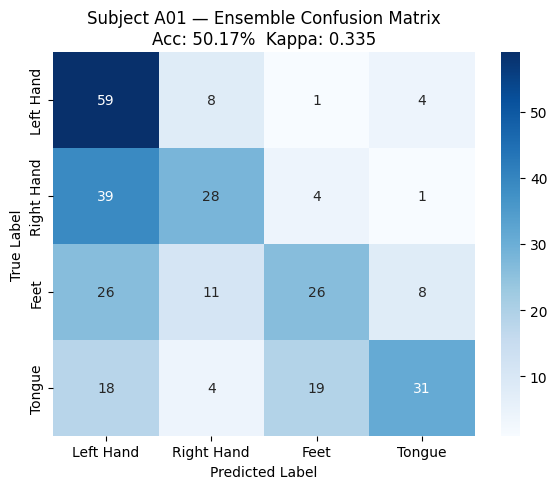

In [9]:
CLASS_NAMES = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

# ── Single subject test ───────────────────────────────────────
SUBJECT = 1
result  = run_subject_full(SUBJECT, DATA_PATH, TRUE_LABELS_PATH)

print(f"\n{'='*50}")
print(f" Subject A0{SUBJECT} — Detailed Results")
print(f"{'='*50}")
print(f"  FBCSP+LDA : Acc={result['csp'][0]*100:.2f}%   Kappa={result['csp'][1]:.4f}")
print(f"  EEGNet    : Acc={result['eegnet'][0]*100:.2f}%   Kappa={result['eegnet'][1]:.4f}")
print(f"  Ensemble  : Acc={result['ensemble'][0]*100:.2f}%   Kappa={result['ensemble'][1]:.4f}")

print("\nClassification Report (Ensemble):")
print(classification_report(result['y_true'], result['y_pred_ensemble'],
                             target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(result['y_true'], result['y_pred_ensemble'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Subject A0{SUBJECT} — Ensemble Confusion Matrix\n'
          f'Acc: {result["ensemble"][0]*100:.2f}%  Kappa: {result["ensemble"][1]:.3f}')
plt.tight_layout()
plt.show()

## Step 8: Run All 9 Subjects


 Subject A01
Loading...
  Train: (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(71), np.int64(1): np.int64(72), np.int64(2): np.int64(72), np.int64(3): np.int64(72)}
  Eval:  (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(71), np.int64(3): np.int64(72)}

── Pipeline A: FBCSP + LDA ──────────────────
  FBCSP CV-acc (train): 55.4%
  FBCSP+LDA → Acc: 51.22%   Kappa: 0.3495

── Pipeline B: EEGNet ───────────────────────
  Augmented: 287 → 861 trials
  EEGNet best epoch: 170
  EEGNet val-acc (train): 95.4%
  EEGNet    → Acc: 41.81%   Kappa: 0.2238

── Adaptive Ensemble ────────────────────────
  Weights → FBCSP: 0.37   EEGNet: 0.63  (from CV 55.4% vs 95.4%)
  Ensemble  → Acc: 51.92%   Kappa: 0.3587

 Subject A02
Loading...
  Train: (287, 22, 751)  sfreq=250.0Hz  classes={np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(71), np.int64(3): np.int64(72)}
  Eval:  (287, 22, 751)  sfreq

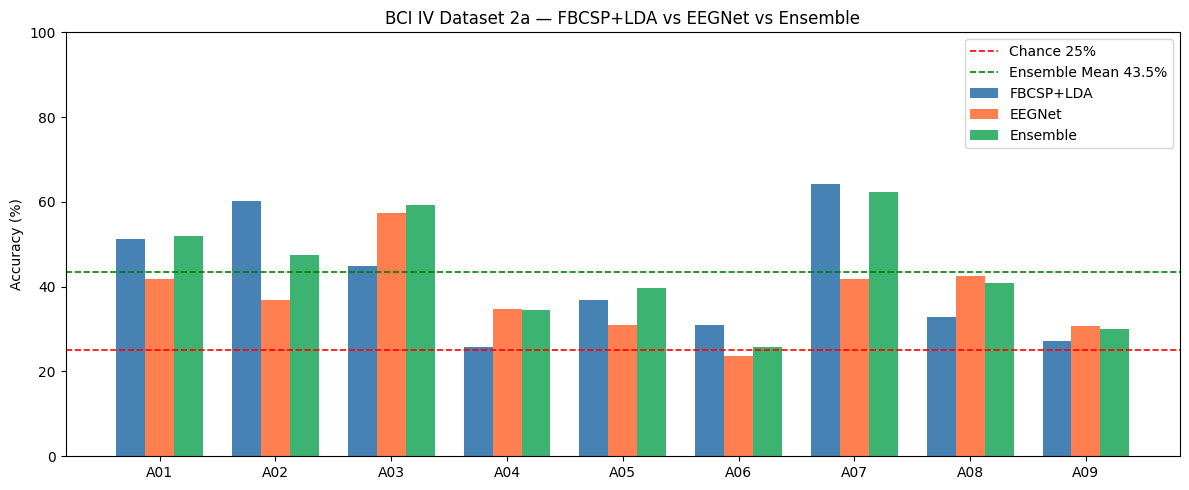

In [10]:
all_results = {}

for sid in range(1, 10):
    try:
        all_results[sid] = run_subject_full(sid, DATA_PATH, TRUE_LABELS_PATH)
    except Exception as e:
        print(f"  Subject A0{sid} FAILED: {e}")
        all_results[sid] = None

# ── Summary Table ─────────────────────────────────────────────
print("\n" + "="*82)
print(f"{'Subject':<10} {'FBCSP+LDA':>14} {'EEGNet':>14} {'Weights':>12} {'Ensemble':>14}")
print(f"{'':10} {'Acc  Kappa':>14} {'Acc  Kappa':>14} {'CSP / EEG':>12} {'Acc  Kappa':>14}")
print("-"*82)

csp_accs, eeg_accs, ens_accs = [], [], []
csp_kaps, eeg_kaps, ens_kaps = [], [], []

for sid, r in all_results.items():
    if r is None:
        print(f"  A0{sid}         FAILED")
        continue
    ca, ck = r['csp']
    ea, ek = r['eegnet']
    na, nk = r['ensemble']
    wc, we = r['weights']
    print(f"  A0{sid}      {ca*100:>6.2f}% {ck:>6.3f}   "
          f"{ea*100:>6.2f}% {ek:>6.3f}   "
          f"{wc:.2f}/{we:.2f}   "
          f"{na*100:>6.2f}% {nk:>6.3f}")
    csp_accs.append(ca); csp_kaps.append(ck)
    eeg_accs.append(ea); eeg_kaps.append(ek)
    ens_accs.append(na); ens_kaps.append(nk)

print("-"*82)
if csp_accs:
    print(f"  Mean     {np.mean(csp_accs)*100:>6.2f}% {np.mean(csp_kaps):>6.3f}   "
          f"{np.mean(eeg_accs)*100:>6.2f}% {np.mean(eeg_kaps):>6.3f}   "
          f"  —         "
          f"{np.mean(ens_accs)*100:>6.2f}% {np.mean(ens_kaps):>6.3f}")
print("="*82)

# ── Bar chart comparing all three approaches ──────────────────
if csp_accs:
    sids  = [f"A0{s}" for s in range(1,10) if all_results[s] is not None]
    x     = np.arange(len(sids))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    b1 = ax.bar(x - width, [a*100 for a in csp_accs], width, label='FBCSP+LDA', color='steelblue')
    b2 = ax.bar(x,         [a*100 for a in eeg_accs], width, label='EEGNet',    color='coral')
    b3 = ax.bar(x + width, [a*100 for a in ens_accs], width, label='Ensemble',  color='mediumseagreen')

    ax.axhline(25,                    color='red',    linestyle='--', lw=1.2, label='Chance 25%')
    ax.axhline(np.mean(ens_accs)*100, color='green',  linestyle='--', lw=1.2,
               label=f'Ensemble Mean {np.mean(ens_accs)*100:.1f}%')

    ax.set_xticks(x)
    ax.set_xticklabels(sids)
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.set_title('BCI IV Dataset 2a — FBCSP+LDA vs EEGNet vs Ensemble')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()